# Import and Setup

In [ ]:

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch version: {torch.__version__}")
print(f"NumPy version: {np.__version__}")

PyTorch version: 2.11.0+cpu
NumPy version: 2.0.2


# Data Generation Function: Creating Synthetic Microstructures


In [ ]:
# We generate 4 distinct steel phases with physics-inspired patterns.
def generate_microstructure_data(num_samples=2000, img_size=28):
    """
    Generate synthetic microstructures with 4 steel phases.

    Returns:
        images: numpy array of shape (num_samples, img_size, img_size)
        labels: numpy array of shape (num_samples,)
    """
    images = []
    labels = []
    samples_per_class = num_samples // 4

    phase_names = ['Pearlite', 'Martensite', 'Austenite', 'Ferrite']

    print("\n" + "="*65)
    print("GENERATING SYNTHETIC MICROSTRUCTURES")
    print("="*65)

    for class_id in range(4):
        print(f"  Generating {samples_per_class} samples of {phase_names[class_id]}...")

        for _ in range(samples_per_class):
            img = np.zeros((img_size, img_size), dtype=np.float32)

            if class_id == 0:  # PEARLITE - Lamellar banding
                period = np.random.randint(3, 8)
                angle = np.random.choice([0, 45, 90, 135])

                for i in range(img_size):
                    for j in range(img_size):
                        if angle == 0:
                            phase_val = np.sin(2 * np.pi * i / period)
                        elif angle == 90:
                            phase_val = np.sin(2 * np.pi * j / period)
                        elif angle == 45:
                            phase_val = np.sin(2 * np.pi * (i + j) / (period*1.4))
                        else:
                            phase_val = np.sin(2 * np.pi * (i - j) / (period*1.4))

                        img[i, j] = 0.3 + 0.5 * (0.5 + 0.5 * phase_val)

                img += np.random.normal(0, 0.04, img.shape)

            elif class_id == 1:  # MARTENSITE - Acicular needles
                img = np.random.normal(0.4, 0.08, (img_size, img_size))
                num_needles = np.random.randint(12, 22)

                for _ in range(num_needles):
                    x1, y1 = np.random.randint(3, 25, 2)
                    length = np.random.randint(5, 11)
                    angle = np.random.uniform(-0.6, 0.6)

                    x2 = int(x1 + length * np.cos(angle))
                    y2 = int(y1 + length * np.sin(angle))

                    for t in np.linspace(0, 1, length * 2):
                        ix = int(x1 + t * (x2 - x1))
                        iy = int(y1 + t * (y2 - y1))
                        if 0 <= ix < img_size and 0 <= iy < img_size:
                            img[ix, iy] = np.random.uniform(0.7, 0.95)

                mask = np.random.rand(img_size, img_size) < 0.15
                img[mask] = np.random.uniform(0.6, 0.9, size=np.sum(mask))

            elif class_id == 2:  # AUSTENITE - Precipitate clusters
                img = np.random.normal(0.35, 0.07, (img_size, img_size))
                num_clusters = np.random.randint(4, 9)

                for _ in range(num_clusters):
                    center_x = np.random.randint(5, 23)
                    center_y = np.random.randint(5, 23)
                    radius = np.random.randint(2, 5)
                    intensity = np.random.uniform(0.7, 0.9)

                    for i in range(max(0, center_x - radius), min(img_size, center_x + radius)):
                        for j in range(max(0, center_y - radius), min(img_size, center_y + radius)):
                            dist = np.sqrt((i - center_x)**2 + (j - center_y)**2)
                            if dist < radius:
                                img[i, j] = intensity * (1 - 0.4 * dist/radius)

                img += np.random.normal(0, 0.04, img.shape)

            else:  # FERRITE - Polygonal grains
                img = np.random.normal(0.55, 0.09, (img_size, img_size))
                grain_size = 4

                for i in range(0, img_size, grain_size):
                    for j in range(0, img_size, grain_size):
                        grain_val = np.random.uniform(0.4, 0.7)
                        i_end = min(i + grain_size, img_size)
                        j_end = min(j + grain_size, img_size)
                        img[i:i_end, j:j_end] = grain_val + np.random.normal(0, 0.04, (i_end-i, j_end-j))

            # Normalize and clip
            img = np.clip(img, 0.0, 1.0)
            images.append(img)
            labels.append(class_id)

    # Convert to numpy arrays
    images = np.array(images, dtype=np.float32)
    labels = np.array(labels, dtype=np.int64)

    print("\n" + "="*65)
    print("DATA GENERATION COMPLETE")
    print("="*65)
    print(f"  Images shape: {images.shape}")
    print(f"  Labels shape: {labels.shape}")
    print(f"  Value range: [{images.min():.2f}, {images.max():.2f}]")
    print("="*65 + "\n")

    return images, labels

## Generate The Raw Data

In [ ]:
# Generate the raw data
images, labels = generate_microstructure_data(num_samples=2000, img_size=28)

# Store class names for later use
CLASS_NAMES = ['Pearlite', 'Martensite', 'Austenite', 'Ferrite']


GENERATING SYNTHETIC MICROSTRUCTURES
  Generating 500 samples of Pearlite...
  Generating 500 samples of Martensite...
  Generating 500 samples of Austenite...
  Generating 500 samples of Ferrite...

DATA GENERATION COMPLETE
  Images shape: (2000, 28, 28)
  Labels shape: (2000,)
  Value range: [0.00, 1.00]



## Visualize All Four Phases

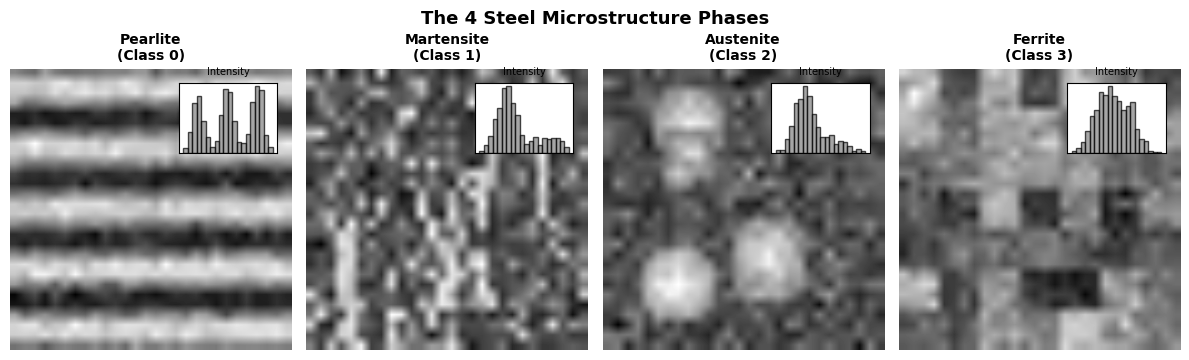


✓ Each phase has distinct visual characteristics:
  • Pearlite:   Alternating light/dark bands (lamellar)
  • Martensite: Sharp needle-like structures (acicular)
  • Austenite:  Rounded blob clusters (precipitates)
  • Ferrite:    Uniform polygonal grains


In [ ]:
# ## 2. Visualization: Understanding Our Synthetic Microstructures
# Before creating data loaders, let's understand what we generated.
def visualize_all_phases(images, labels, class_names):
    """Display one example of each phase"""
    fig, axes = plt.subplots(1, 4, figsize=(12, 3.5))

    for phase_id in range(4):
        # Find first image of this phase
        idx = np.where(labels == phase_id)[0][0]
        img = images[idx]

        axes[phase_id].imshow(img, cmap='gray', interpolation='bilinear')
        axes[phase_id].set_title(f'{class_names[phase_id]}\n(Class {phase_id})',
                                  fontsize=10, fontweight='bold')
        axes[phase_id].axis('off')

        # Add intensity histogram inset
        ax_hist = axes[phase_id].inset_axes([0.6, 0.7, 0.35, 0.25])
        ax_hist.hist(img.flatten(), bins=20, color='gray', alpha=0.7, edgecolor='black')
        ax_hist.set_xticks([])
        ax_hist.set_yticks([])
        ax_hist.set_title('Intensity', fontsize=7)

    plt.suptitle('The 4 Steel Microstructure Phases',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    print("\n✓ Each phase has distinct visual characteristics:")
    print("  • Pearlite:   Alternating light/dark bands (lamellar)")
    print("  • Martensite: Sharp needle-like structures (acicular)")
    print("  • Austenite:  Rounded blob clusters (precipitates)")
    print("  • Ferrite:    Uniform polygonal grains")
visualize_all_phases(images, labels, CLASS_NAMES)

## Class Distribution Check

In [ ]:
def check_class_distribution(labels, class_names):
    """Verify balanced dataset"""
    unique, counts = np.unique(labels, return_counts=True)

    print("\n" + "="*50)
    print("CLASS DISTRIBUTION")
    print("="*50)
    for class_id, count in zip(unique, counts):
        print(f"  {class_names[class_id]:12s}: {count:4d} samples ({count/len(labels)*100:.1f}%)")
    print("="*50)

check_class_distribution(labels, CLASS_NAMES)


CLASS DISTRIBUTION
  Pearlite    :  500 samples (25.0%)
  Martensite  :  500 samples (25.0%)
  Austenite   :  500 samples (25.0%)
  Ferrite     :  500 samples (25.0%)


## Inspect Raw Pixel Values (What CNN Sees)

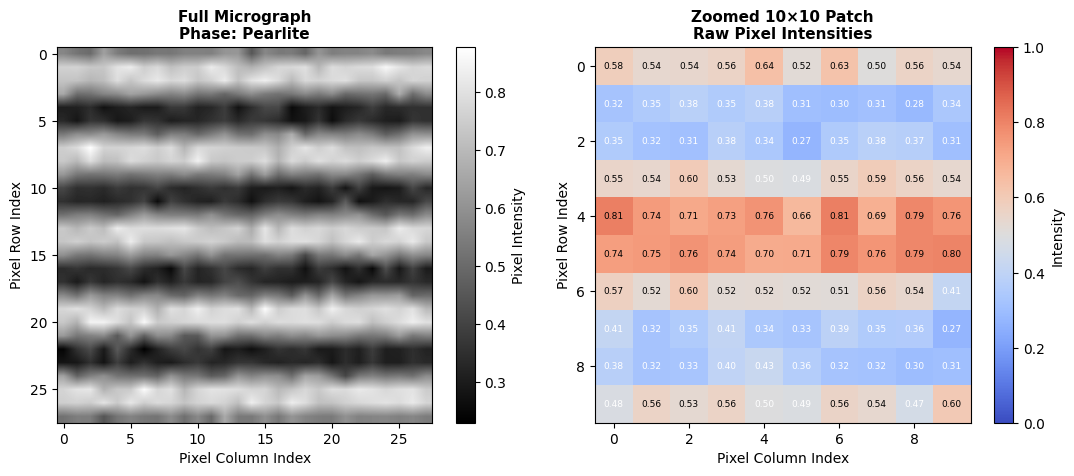


THE CNN SEES EXACTLY THIS MATRIX OF NUMBERS:
Row 0: 0.58  0.54  0.54  0.56  0.64  0.52  0.63  0.50  0.56  0.54
Row 1: 0.32  0.35  0.38  0.35  0.38  0.31  0.30  0.31  0.28  0.34
Row 2: 0.35  0.32  0.31  0.38  0.34  0.27  0.35  0.38  0.37  0.31
Row 3: 0.55  0.54  0.60  0.53  0.50  0.49  0.55  0.59  0.56  0.54
Row 4: 0.81  0.74  0.71  0.73  0.76  0.66  0.81  0.69  0.79  0.76
-----------------------------------------------------------------
Each pixel = 0.00 (dark) to 1.00 (light)
The CNN has no concept of 'phases' - only numbers!



In [ ]:
# 3. What the Neural Network Actually Sees
# A micrograph is just a matrix of numbers to the CNN.
def inspect_raw_pixel_values(images, labels, class_names):
    """Extract one sample and show raw pixel values"""
    # Get first sample
    img = images[0]
    label = labels[0]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

    # LEFT: Full image
    im1 = ax1.imshow(img, cmap='gray', interpolation='bilinear')
    ax1.set_title(f"Full Micrograph\nPhase: {class_names[label]}",
                  fontsize=11, fontweight='bold')
    ax1.set_xlabel("Pixel Column Index")
    ax1.set_ylabel("Pixel Row Index")
    plt.colorbar(im1, ax=ax1, label='Pixel Intensity')

    # RIGHT: Zoomed 10x10 patch
    h, w = img.shape
    patch = img[h//2-5:h//2+5, w//2-5:w//2+5]

    im2 = ax2.imshow(patch, cmap='coolwarm', vmin=0, vmax=1, interpolation='nearest')
    ax2.set_title("Zoomed 10×10 Patch\nRaw Pixel Intensities",
                  fontsize=11, fontweight='bold')
    ax2.set_xlabel("Pixel Column Index")
    ax2.set_ylabel("Pixel Row Index")

    # Add numerical annotations
    for i in range(10):
        for j in range(10):
            color = 'white' if patch[i, j] < 0.5 else 'black'
            ax2.text(j, i, f"{patch[i, j]:.2f}", ha="center", va="center",
                    color=color, fontsize=6.5)

    plt.colorbar(im2, ax=ax2, label='Intensity')
    plt.tight_layout()
    plt.show()

    # Print the matrix
    print("\n" + "="*65)
    print("THE CNN SEES EXACTLY THIS MATRIX OF NUMBERS:")
    print("="*65)
    for i in range(5):
        row = "  ".join([f"{patch[i, j]:.2f}" for j in range(10)])
        print(f"Row {i}: {row}")
    print("-"*65)
    print("Each pixel = 0.00 (dark) to 1.00 (light)")
    print("The CNN has no concept of 'phases' - only numbers!")
    print("="*65 + "\n")

# %%
inspect_raw_pixel_values(images, labels, CLASS_NAMES)

## Display Multiple Random Samples

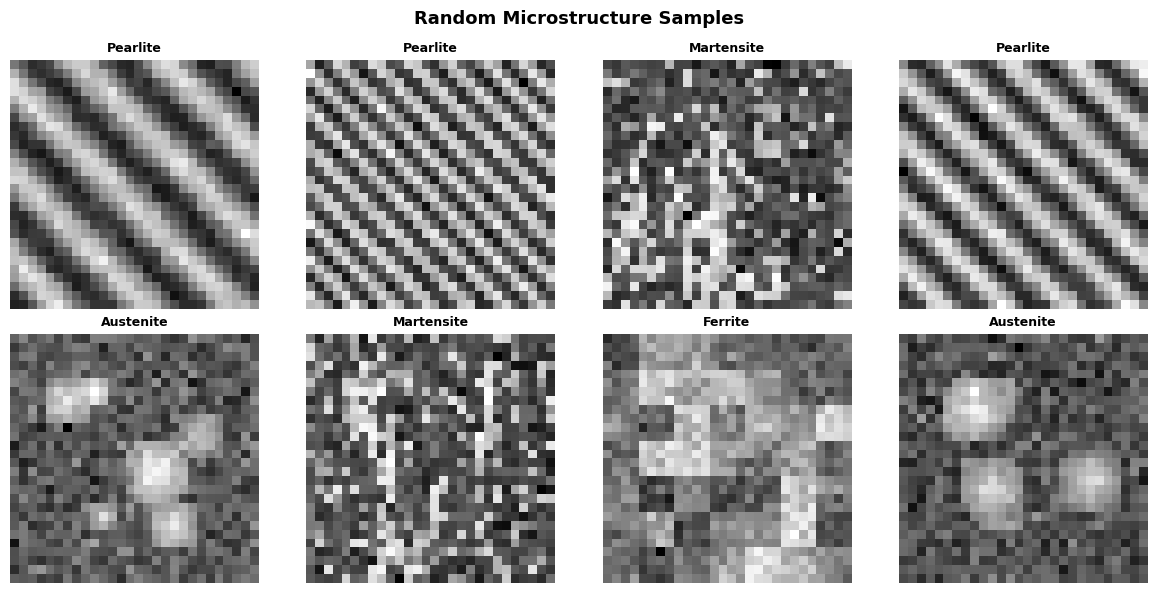

In [ ]:
def visualize_random_samples(images, labels, class_names, num_samples=8):
    """Display random samples with their labels"""
    indices = np.random.choice(len(images), num_samples, replace=False)

    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    axes = axes.flatten()

    for i, idx in enumerate(indices):
        axes[i].imshow(images[idx], cmap='gray')
        axes[i].set_title(f"{class_names[labels[idx]]}", fontsize=9, fontweight='bold')
        axes[i].axis('off')

    plt.suptitle('Random Microstructure Samples', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
visualize_random_samples(images, labels, CLASS_NAMES, num_samples=8)

# Data Loader

In [ ]:
def create_data_loaders(images, labels, batch_size=32, test_split=0.2):
    """Convert numpy arrays to PyTorch DataLoaders"""
    # Add channel dimension: (N, H, W) -> (N, 1, H, W)
    images = np.expand_dims(images, axis=1)

    # Convert to tensors
    images_tensor = torch.tensor(images, dtype=torch.float32)
    labels_tensor = torch.tensor(labels, dtype=torch.long)

    # Train/validation/test split (train 80%, val 10%, test 10%)
    from sklearn.model_selection import train_test_split

    # First split: train (80%) and temp (20%)
    X_train, X_temp, y_train, y_temp = train_test_split(
        images_tensor, labels_tensor,
        test_size=0.2, stratify=labels_tensor, random_state=42
    )

    # Second split: val (10%) and test (10%) from temp (half of 20% = 10% each)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=0.5, stratify=y_temp, random_state=42
    )

    # Create datasets
    train_dataset = TensorDataset(X_train, y_train)
    val_dataset = TensorDataset(X_val, y_val)
    test_dataset = TensorDataset(X_test, y_test)

    # Create loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    print("\n" + "="*65)
    print("DATALOADER SUMMARY")
    print("="*65)
    print(f"  Total samples: {len(images_tensor)}")
    print(f"  Train samples: {len(train_dataset)} ({len(train_loader)} batches)")
    print(f"  Val samples:   {len(val_dataset)} ({len(val_loader)} batches)")
    print(f"  Test samples:  {len(test_dataset)} ({len(test_loader)} batches)")
    print(f"  Batch size:    {batch_size}")
    print("="*65 + "\n")

    return train_loader, val_loader, test_loader



In [ ]:
# %%
# Create all three loaders
train_loader, val_loader, test_loader = create_data_loaders(images, labels, batch_size=32)

# Verify they exist
print(f"✓ train_loader created: {type(train_loader)}")
print(f"✓ val_loader created:   {type(val_loader)}")
print(f"✓ test_loader created:  {type(test_loader)}")


DATALOADER SUMMARY
  Total samples: 2000
  Train samples: 1600 (50 batches)
  Val samples:   200 (7 batches)
  Test samples:  200 (7 batches)
  Batch size:    32

✓ train_loader created: <class 'torch.utils.data.dataloader.DataLoader'>
✓ val_loader created:   <class 'torch.utils.data.dataloader.DataLoader'>
✓ test_loader created:  <class 'torch.utils.data.dataloader.DataLoader'>


## Inspect Data Loader Batch

In [ ]:
# Quick verification: inspect one batch
def inspect_dataloader_batch(loader):
    """Verify DataLoader returns correct shapes"""
    images_batch, labels_batch = next(iter(loader))

    print("\n" + "="*50)
    print("DATALOADER VERIFICATION")
    print("="*50)
    print(f"  Batch images shape: {images_batch.shape}")
    print(f"  Batch labels shape: {labels_batch.shape}")
    print(f"  Image value range: [{images_batch.min():.2f}, {images_batch.max():.2f}]")
    print(f"  Labels in batch: {labels_batch.tolist()}")
    print("="*50)

# %%
inspect_dataloader_batch(train_loader)


DATALOADER VERIFICATION
  Batch images shape: torch.Size([32, 1, 28, 28])
  Batch labels shape: torch.Size([32])
  Image value range: [0.08, 0.95]
  Labels in batch: [0, 3, 3, 0, 2, 0, 3, 2, 1, 2, 1, 2, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 3, 3, 0, 3, 0, 3, 3, 0, 2, 1]


# CNN MODEL

## Define CNN Architecture

In [ ]:
# 5. CNN Model Definition
# Now that our data is ready, we define the neural network.
class MicrostructureCNN(nn.Module):
    """
    2D CNN for 4-class steel microstructure classification.
    """

    def __init__(self, input_channels=1, num_classes=4):
        super(MicrostructureCNN, self).__init__()

        self.features = nn.Sequential(
            # Block 1: Edge detection
            nn.Conv2d(input_channels, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 28x28 -> 14x14

            # Block 2: Pattern composition
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 14x14 -> 7x7
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# %%
model = MicrostructureCNN(input_channels=1, num_classes=4)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

MicrostructureCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=4, bias=True)
  )
)

Total parameters: 420,868


## Training Model

In [ ]:
# Standard Training Loop with Validation
# This is the **industry standard** training function used in research and production.
def train_model(model, train_loader, val_loader, epochs=20, lr=0.001, device='cpu'):
    """
    Standard training loop with validation tracking.

    This is the canonical PyTorch training pattern used in:
    - Research papers
    - Production systems
    - Kaggle competitions

    Args:
        model: PyTorch model
        train_loader: DataLoader for training
        val_loader: DataLoader for validation
        epochs: Number of training epochs
        lr: Learning rate
        device: 'cuda' or 'cpu'

    Returns:
        model: Trained model
        history: Dictionary with 'train_loss', 'val_loss', 'train_acc', 'val_acc'
    """
    # Move model to device
    model = model.to(device)

    # Loss function and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Store history for visualization
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': []
    }

    print("\n" + "="*65)
    print("STANDARD TRAINING LOOP")
    print("="*65)
    print(f"Device: {device.upper()}")
    print(f"Epochs: {epochs} | Learning rate: {lr} | Optimizer: Adam")
    print("-"*65)

    for epoch in range(epochs):
        # ========== TRAINING PHASE ==========
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:
            # Move data to device
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Metrics
            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        avg_train_loss = train_loss / len(train_loader)
        train_accuracy = train_correct / train_total

        # ========== VALIDATION PHASE ==========
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        avg_val_loss = val_loss / len(val_loader)
        val_accuracy = val_correct / val_total

        # Store history
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_acc'].append(train_accuracy)
        history['val_acc'].append(val_accuracy)

        # Print progress
        print(f"Epoch {epoch+1:2d}/{epochs} | "
              f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | "
              f"Train Acc: {train_accuracy:.2%} | Val Acc: {val_accuracy:.2%}")

    print("="*65 + "\n")
    return model, history

In [ ]:
# Check for GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device.upper()}")

# Train the model
model = MicrostructureCNN(input_channels=1, num_classes=4)
trained_model, history = train_model(
    model, train_loader, val_loader,
    epochs=20, lr=0.001, device=device
)

Using device: CPU

STANDARD TRAINING LOOP
Device: CPU
Epochs: 20 | Learning rate: 0.001 | Optimizer: Adam
-----------------------------------------------------------------
Epoch  1/20 | Train Loss: 0.9096 | Val Loss: 0.1757 | Train Acc: 63.50% | Val Acc: 98.00%
Epoch  2/20 | Train Loss: 0.1192 | Val Loss: 0.0131 | Train Acc: 96.88% | Val Acc: 100.00%
Epoch  3/20 | Train Loss: 0.0215 | Val Loss: 0.0017 | Train Acc: 99.81% | Val Acc: 100.00%
Epoch  4/20 | Train Loss: 0.0105 | Val Loss: 0.0010 | Train Acc: 99.88% | Val Acc: 100.00%
Epoch  5/20 | Train Loss: 0.0061 | Val Loss: 0.0003 | Train Acc: 100.00% | Val Acc: 100.00%
Epoch  6/20 | Train Loss: 0.0045 | Val Loss: 0.0003 | Train Acc: 100.00% | Val Acc: 100.00%
Epoch  7/20 | Train Loss: 0.0038 | Val Loss: 0.0002 | Train Acc: 100.00% | Val Acc: 100.00%
Epoch  8/20 | Train Loss: 0.0167 | Val Loss: 0.0231 | Train Acc: 99.62% | Val Acc: 99.50%
Epoch  9/20 | Train Loss: 0.0147 | Val Loss: 0.0002 | Train Acc: 99.69% | Val Acc: 100.00%
Epoch 10

## Plot Loss Surface

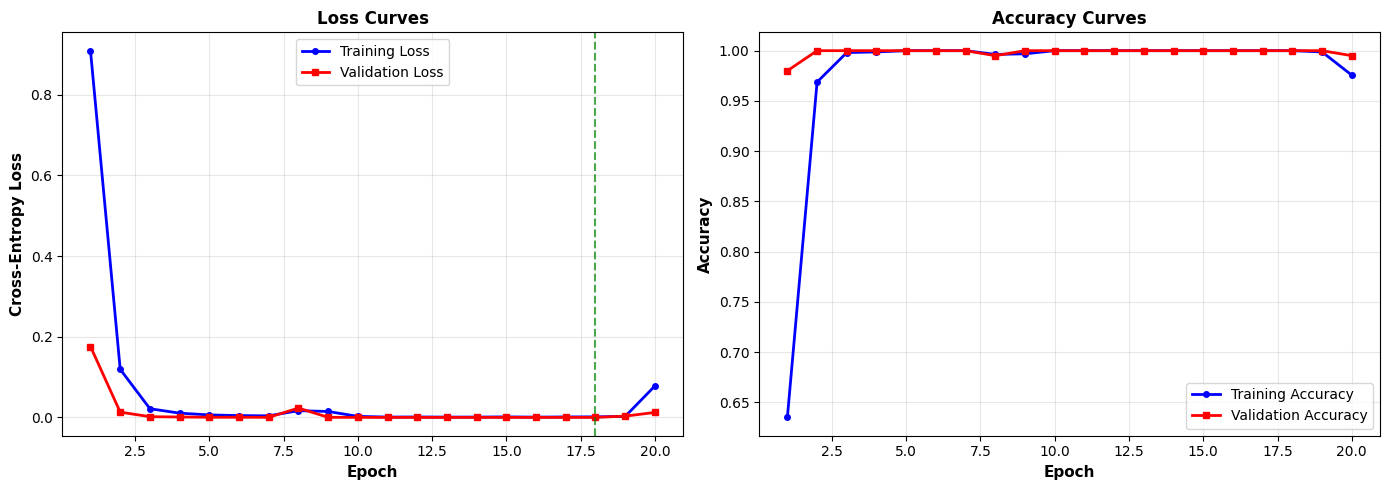


TRAINING DIAGNOSTICS
  Best validation loss: 0.0000 (epoch 18)
  Final train loss:     0.0780
  Final val loss:       0.0123
  Final train acc:      97.56%
  Final val acc:        99.50%

  ✅ Good generalization (gap: -0.0657)



In [ ]:
# ## 7. Train-Validation Loss Curves
# These curves diagnose if the model is learning correctly or overfitting.
def plot_loss_curves(history):
    """Plot training and validation loss/accuracy curves."""
    epochs = range(1, len(history['train_loss']) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Loss curves
    ax1.plot(epochs, history['train_loss'], 'b-', linewidth=2, label='Training Loss', marker='o', markersize=4)
    ax1.plot(epochs, history['val_loss'], 'r-', linewidth=2, label='Validation Loss', marker='s', markersize=4)
    ax1.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Cross-Entropy Loss', fontsize=11, fontweight='bold')
    ax1.set_title('Loss Curves', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)

    # Find best epoch
    best_epoch = np.argmin(history['val_loss']) + 1
    ax1.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7,
                label=f'Best model (epoch {best_epoch})')

    # Accuracy curves
    ax2.plot(epochs, history['train_acc'], 'b-', linewidth=2, label='Training Accuracy', marker='o', markersize=4)
    ax2.plot(epochs, history['val_acc'], 'r-', linewidth=2, label='Validation Accuracy', marker='s', markersize=4)
    ax2.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
    ax2.set_title('Accuracy Curves', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Diagnostic summary
    print("\n" + "="*65)
    print("TRAINING DIAGNOSTICS")
    print("="*65)
    print(f"  Best validation loss: {min(history['val_loss']):.4f} (epoch {best_epoch})")
    print(f"  Final train loss:     {history['train_loss'][-1]:.4f}")
    print(f"  Final val loss:       {history['val_loss'][-1]:.4f}")
    print(f"  Final train acc:      {history['train_acc'][-1]:.2%}")
    print(f"  Final val acc:        {history['val_acc'][-1]:.2%}")

    # Overfitting check
    gap = history['val_loss'][-1] - history['train_loss'][-1]
    if gap > 0.1:
        print(f"\n  ⚠️  Potential overfitting (gap: {gap:.4f})")
    else:
        print(f"\n  ✅ Good generalization (gap: {gap:.4f})")
    print("="*65 + "\n")

# %%
plot_loss_curves(history)

# Evaluation on Test Set

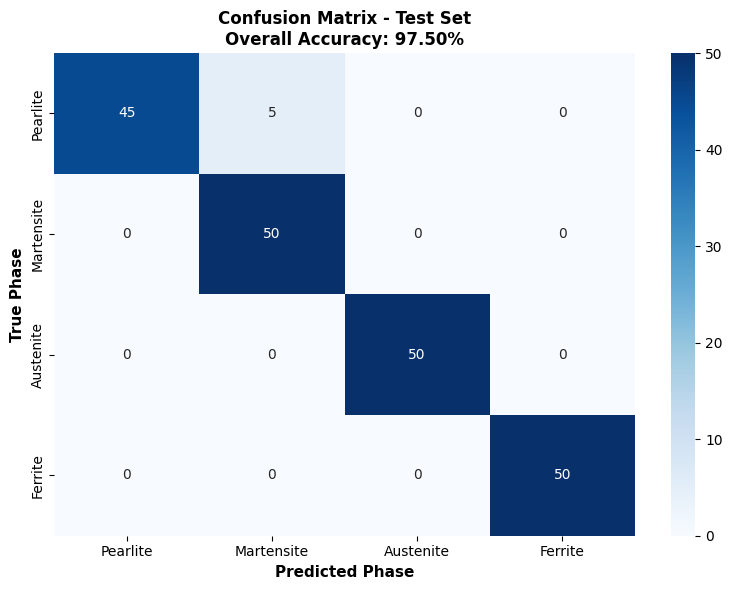


PER-CLASS ACCURACY (Test Set)
  Pearlite    :  45/ 50 (90.0%)
  Martensite  :  50/ 50 (100.0%)
  Austenite   :  50/ 50 (100.0%)
  Ferrite     :  50/ 50 (100.0%)


In [ ]:
# ## 8. Evaluation: Confusion Matrix on Test Set

# %%
def evaluate_model(model, test_loader, device='cpu', class_names=None):
    """Evaluate model on test set and plot confusion matrix."""
    if class_names is None:
        class_names = ['Pearlite', 'Martensite', 'Austenite', 'Ferrite']

    model.eval()
    model = model.to(device)
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    acc = np.sum(cm.diagonal()) / np.sum(cm)

    # Plot
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Phase', fontsize=11, fontweight='bold')
    plt.ylabel('True Phase', fontsize=11, fontweight='bold')
    plt.title(f'Confusion Matrix - Test Set\nOverall Accuracy: {acc:.2%}',
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Per-class accuracy
    print("\n" + "="*50)
    print("PER-CLASS ACCURACY (Test Set)")
    print("="*50)
    for i, name in enumerate(class_names):
        correct = cm[i, i]
        total = np.sum(cm[i, :])
        print(f"  {name:12s}: {correct:3d}/{total:3d} ({correct/total:.1%})")
    print("="*50)

    return cm, acc

# %%
cm, test_acc = evaluate_model(trained_model, test_loader, device=device, class_names=CLASS_NAMES)

# Demo on Random Samples

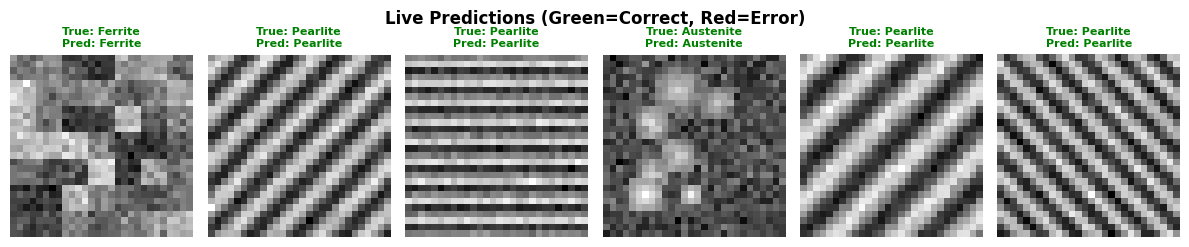

In [ ]:
# Live Demonstration

# %%
def demo_predictions(model, test_loader, device='cpu', n=6):
    """Show side-by-side predictions with true labels."""
    model.eval()
    class_names = ['Pearlite', 'Martensite', 'Austenite', 'Ferrite']

    # Get one batch
    images, labels = next(iter(test_loader))
    images = images.to(device)

    with torch.no_grad():
        outputs = model(images[:n])
        _, preds = torch.max(outputs, 1)

    fig, axes = plt.subplots(1, n, figsize=(12, 2.5))
    for i in range(n):
        img = images[i, 0].cpu().numpy()
        axes[i].imshow(img, cmap='gray')
        color = 'green' if preds[i] == labels[i] else 'red'
        axes[i].set_title(f"True: {class_names[labels[i]]}\nPred: {class_names[preds[i]]}",
                          fontsize=8, color=color, fontweight='bold')
        axes[i].axis('off')

    plt.suptitle('Live Predictions (Green=Correct, Red=Error)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

# %%
demo_predictions(trained_model, test_loader, device=device, n=6)

# Feature Map Visualization - What Each Conv Layer Sees


🔬 ANALYZING HOW DEPTH ENABLES COMPOUND FEATURE LEARNING
The deeper the layer, the more complex the spatial patterns...



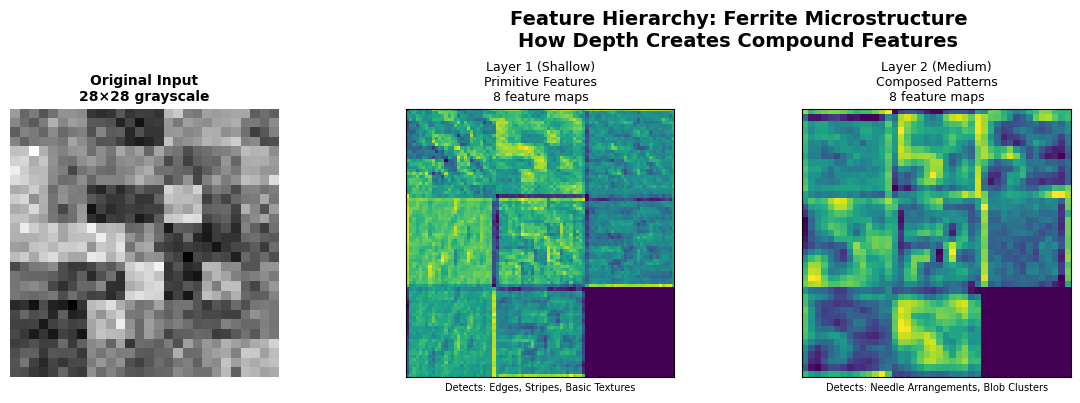


📊 DEPTH ANALYSIS: Ferrite
  Layer 1 (Shallow): Learns primitive features like edges and stripes
    → What a metallurgist sees: Individual cementite lamellae or martensite needles
  
  Layer 2 (Medium): Combines primitives into patterns
    → What a metallurgist sees: Arrangements of needles or clustered precipitates
  
  Layer 3+ (Deep): Recognizes complete phase characteristics
    → What a metallurgist sees: 'This is pearlite' or 'This is martensite'



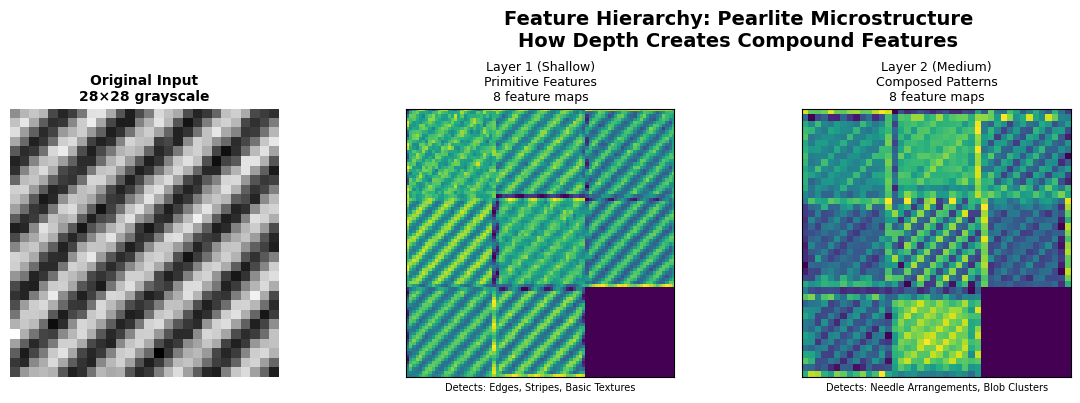


📊 DEPTH ANALYSIS: Pearlite
  Layer 1 (Shallow): Learns primitive features like edges and stripes
    → What a metallurgist sees: Individual cementite lamellae or martensite needles
  
  Layer 2 (Medium): Combines primitives into patterns
    → What a metallurgist sees: Arrangements of needles or clustered precipitates
  
  Layer 3+ (Deep): Recognizes complete phase characteristics
    → What a metallurgist sees: 'This is pearlite' or 'This is martensite'



In [ ]:
#  Feature Visualization: How Depth Enables Hierarchical Feature Learning
#
# **Critical AI Concept:** Deeper networks learn **compound features** - from simple edges to complex phase patterns.
#
# - **Layer 1 (shallow):** Primitive edges, stripes, basic textures
# - **Layer 2 (medium):** Composed patterns (needle arrangements, blob clusters)
# - **Layer 3 (deep):** Phase-specific spatial relationships
#
# For materials science: The network builds understanding like a metallurgist would - from individual grains → grain boundaries → phase identification.

# %%
def visualize_layer_features(model, test_loader, device='cpu', num_samples=3):
    """
    Extract and visualize feature maps from different convolution layers.
    Demonstrates hierarchical feature learning.
    """
    model.eval()

    # Get a few test samples
    images, labels = next(iter(test_loader))
    images = images[:num_samples].to(device)
    labels = labels[:num_samples]

    # Register hooks to capture intermediate activations
    activation_outputs = {}

    def get_activation(name):
        def hook(model, input, output):
            activation_outputs[name] = output.detach()
        return hook

    # Register hooks for convolution layers
    hooks = []
    for name, layer in model.named_modules():
        if isinstance(layer, nn.Conv2d):
            hooks.append(layer.register_forward_hook(get_activation(f'conv_{name}')))

    # Forward pass
    with torch.no_grad():
        _ = model(images)

    # Remove hooks
    for hook in hooks:
        hook.remove()

    class_names = ['Pearlite', 'Martensite', 'Austenite', 'Ferrite']

    # Visualize for each sample
    for sample_idx in range(num_samples):
        img = images[sample_idx, 0].cpu().numpy()
        true_label = class_names[labels[sample_idx]]

        fig = plt.figure(figsize=(16, 10))
        fig.suptitle(f'Feature Hierarchy: {true_label} Microstructure\n'
                     f'How Depth Creates Compound Features',
                     fontsize=14, fontweight='bold', y=0.98)

        # Original image (top left)
        ax_img = plt.subplot(3, 4, 1)
        ax_img.imshow(img, cmap='gray')
        ax_img.set_title(f'Original Input\n28×28 grayscale', fontsize=10, fontweight='bold')
        ax_img.axis('off')

        # Organize conv layers by depth
        conv_layers = sorted([(name, acts) for name, acts in activation_outputs.items()
                              if 'conv' in name], key=lambda x: x[0])

        # Show feature maps from different depths
        for idx, (layer_name, features) in enumerate(conv_layers):
            # Take first 8 channels for visualization
            num_channels = min(8, features.shape[1])
            feature_maps = features[sample_idx, :num_channels].cpu()

            # Determine grid position
            col = idx + 2  # Start from column 2
            if col <= 4:
                row = 0
                plot_col = col
            else:
                row = 1
                plot_col = col - 4

            # Create subplot for this layer's feature maps
            ax = plt.subplot(3, 4, (row * 4) + plot_col)

            # Combine multiple feature maps into a grid
            grid_size = int(np.ceil(np.sqrt(num_channels)))
            combined = np.zeros((grid_size * feature_maps.shape[1],
                                grid_size * feature_maps.shape[2]))

            for i in range(num_channels):
                r = i // grid_size
                c = i % grid_size
                fm = feature_maps[i].numpy()
                # Normalize for visualization
                fm = (fm - fm.min()) / (fm.max() - fm.min() + 1e-8)
                combined[r*fm.shape[0]:(r+1)*fm.shape[0],
                        c*fm.shape[1]:(c+1)*fm.shape[1]] = fm

            ax.imshow(combined, cmap='viridis')

            # Add layer description
            if idx == 0:
                layer_desc = "Layer 1 (Shallow)\nPrimitive Features"
                insight = "Detects: Edges, Stripes, Basic Textures"
            elif idx == 1:
                layer_desc = "Layer 2 (Medium)\nComposed Patterns"
                insight = "Detects: Needle Arrangements, Blob Clusters"
            else:
                layer_desc = f"Layer {idx+1} (Deep)\nCompound Features"
                insight = "Detects: Phase-Specific Spatial Relationships"

            ax.set_title(f'{layer_desc}\n{num_channels} feature maps', fontsize=9)
            ax.set_xlabel(insight, fontsize=7)
            ax.set_xticks([])
            ax.set_yticks([])

        plt.tight_layout()
        plt.show()

        # Print explanation
        print("\n" + "="*70)
        print(f"📊 DEPTH ANALYSIS: {true_label}")
        print("="*70)
        print(f"  Layer 1 (Shallow): Learns primitive features like edges and stripes")
        print(f"    → What a metallurgist sees: Individual cementite lamellae or martensite needles")
        print(f"  ")
        print(f"  Layer 2 (Medium): Combines primitives into patterns")
        print(f"    → What a metallurgist sees: Arrangements of needles or clustered precipitates")
        print(f"  ")
        print(f"  Layer 3+ (Deep): Recognizes complete phase characteristics")
        print(f"    → What a metallurgist sees: 'This is pearlite' or 'This is martensite'")
        print("="*70 + "\n")

    return activation_outputs

# %%
# Visualize feature hierarchy
print("\n" + "="*70)
print("🔬 ANALYZING HOW DEPTH ENABLES COMPOUND FEATURE LEARNING")
print("="*70)
print("The deeper the layer, the more complex the spatial patterns...\n")

feature_maps = visualize_layer_features(trained_model, test_loader, device=device, num_samples=2)